# CR con prior jerárquico: aceleración de motocicletas

Prototipo con `MASS::mcycle` (133 mediciones de aceleración en impactos simulados).
Datos: [Rdatasets / MASS](https://vincentarelbundock.github.io/Rdatasets/doc/MASS/mcycle.html).
La copia incluida permite ejecutar el ejemplo sin descargar datos.

Requiere la rama `smooths` de formulae indicada en `pyproject.toml`.
Usamos `cr`, que es la abreviatura habitual de cubic regression spline.
Su `eval` devuelve `to_random` y reutiliza el estado de entrenamiento para predecir.

In [1]:
%matplotlib inline

import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("data/mcycle.csv")
data["x"] = data.times
accel_sd = data.accel.std(ddof=0)

Ajustamos `accel` directamente en g y conservamos el tiempo en milisegundos.
Así `model.predict` y `bmb.interpret.plot_predictions` devuelven resultados en g,
sin transformaciones manuales. Bambi no puede inferir la transformación inversa
si la respuesta se estandariza externamente antes de construir el modelo.

Con `center=True`, `cr(x)` no incluye una columna de intercepto: sus dos bloques de
prior son `"linear"` y `"curvature"`. El componente lineal lleva
$\beta_0 \sim N(0, 2.5 s_y)$; los coeficientes de curvatura llevan
$\beta_j \sim N(0, \tau)$, $\tau \sim \mathrm{HalfNormal}(s_y)$,
donde $s_y$ es el desvío estándar de la aceleración observada.
Esto expresa los priors del ejemplo estandarizado en las unidades originales.
Los defaults del prototipo aún no se autoescalan, por eso se especifican aquí.

Se construye un único vector Normal en la dimensión del spline, concatenando la escala
fija del bloque `"linear"` con la escala aleatoria compartida del bloque `"curvature"`.
`to_random` conserva la penalización en las unidades de x.


In [3]:
priors = {
    "cr(x, df=12)": {
        "linear": bmb.Prior("Normal", mu=0, sigma=2.5 * accel_sd),
        "curvature": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=accel_sd)
        ),
    }
}
model = bmb.Model("accel ~ cr(x, df=12)", data, priors=priors)
model.build()
idata = model.fit(
    random_seed=123,
    inference_method="pymc",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, cr(x, df=12)_sigma, cr(x, df=12)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


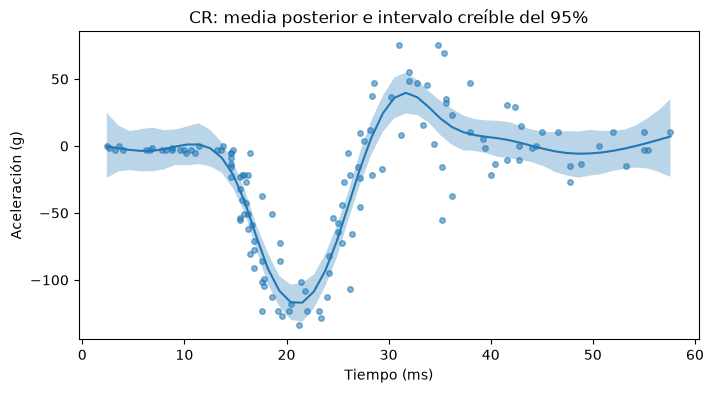

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bmb.interpret.plot_predictions(model, idata, "x", on=ax, prob=0.95)
ax.scatter(data.times, data.accel, s=16, alpha=0.55)
ax.set(
    xlabel="Tiempo (ms)",
    ylabel="Aceleración (g)",
    title="CR: media posterior e intervalo creíble del 95%",
);

In [5]:
priors = {
    "cr(x, df=12, center=False)": {
        "constant": bmb.Prior("Normal", mu=0, sigma=20),
        "linear": bmb.Prior("Normal", mu=0, sigma=2.5 * accel_sd),
        "curvature": bmb.Prior(
            "Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=accel_sd)
        ),
    }
}
model = bmb.Model("accel ~ 0 + cr(x, df=12, center=False)", data, priors=priors)
model.build()
idata = model.fit(
    random_seed=123,
    inference_method="pymc",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, cr(x, df=12, center=False)_sigma, cr(x, df=12, center=False)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


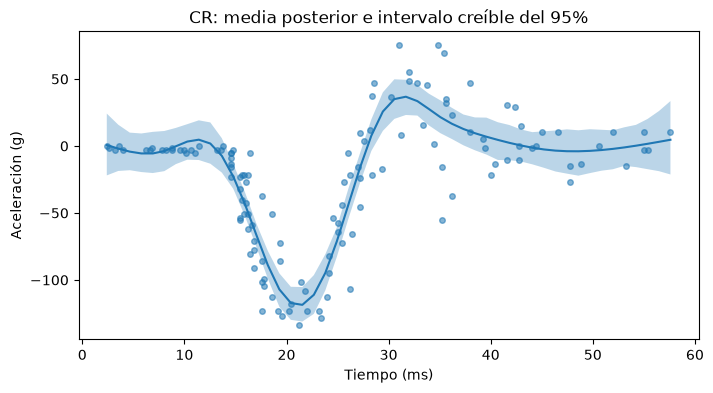

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
bmb.interpret.plot_predictions(model, idata, "x", on=ax, prob=0.95)
ax.scatter(data.times, data.accel, s=16, alpha=0.55)
ax.set(
    xlabel="Tiempo (ms)",
    ylabel="Aceleración (g)",
    title="CR: media posterior e intervalo creíble del 95%",
);

In [7]:
model = bmb.Model("accel ~ 1 + cr(x, df=12)", data)
model.build()
idata = model.fit(
    random_seed=123,
    inference_method="pymc",
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, cr(x, df=12)_sigma, cr(x, df=12)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


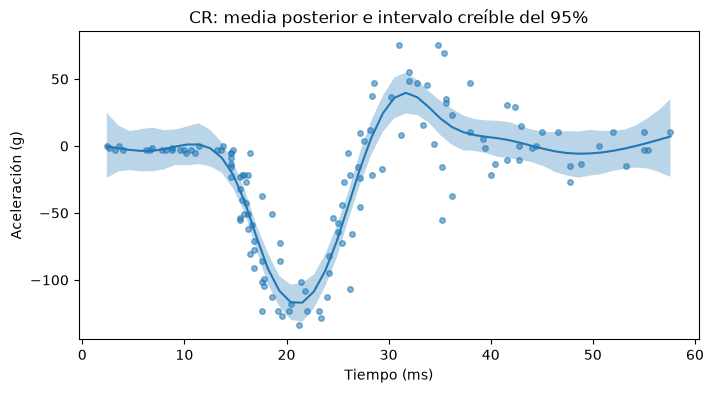

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
bmb.interpret.plot_predictions(model, idata, "x", on=ax, prob=0.95)
ax.scatter(data.times, data.accel, s=16, alpha=0.55)
ax.set(
    xlabel="Tiempo (ms)",
    ylabel="Aceleración (g)",
    title="CR: media posterior e intervalo creíble del 95%",
);